# Paquetes

In [1]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import RandomLayers
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import os
import sys
from PIL import Image
from multiprocessing import Process, Pool, Manager
import pickle

from keras import metrics
from keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, Reshape

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, accuracy_score
from qiskit.quantum_info import SparsePauliOp
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.patches as mpatches
import seaborn as sns

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2024-07-04 09:39:23.992579: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-04 09:39:24.838209: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Num GPUs Available:  8


In [2]:
# os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'
# os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

# Carga de Datos

## Train

In [3]:
extract_dir = "datos_im/train/"
def list_all_files(directory):
    file_paths = []
    for root, directories, files in os.walk(directory):
        for filename in files:
            file_path = os.path.join(root, filename)
            file_paths.append(file_path)
    return file_paths

all_files = list_all_files(extract_dir)

image_files = [f for f in all_files if f.lower().endswith('.png')]

array_shape = (32, 32)
array_shape1 = (32, 32, 3)

image_labels_tr=[]
image_tr = np.empty((len(image_files), *array_shape1),dtype=np.int8)
i=0

for file_path in image_files:
    image_name = os.path.basename(file_path).split('.png')[0]
    folder_name = os.path.basename(os.path.dirname(file_path)).split('_')[0]
    with Image.open(file_path) as img:
        img = img.convert('RGB')
        img = img.resize(array_shape)
        img_array = np.array(img)

    image_labels_tr.append((image_name, folder_name))
    image_tr[i]=img_array

    i+=1

train_imgs_tf = (image_tr / 255)*np.pi
df_tr = pd.DataFrame(image_labels_tr, columns=['image_name', 'class'])

#Mezclamos el df
np.random.seed(5)
indices = np.random.permutation(len(df_tr))
df_tr = df_tr.iloc[indices].reset_index(drop=True)
train_imgs_tf = train_imgs_tf[indices]

print(df_tr.head(10))
print(df_tr.shape)

print(train_imgs_tf.shape)

with open("datos_im/dfs/train_imgs_tf.pkl", "wb") as file:
    pickle.dump(train_imgs_tf, file)

with open("datos_im/dfs/df_tr.pkl", "wb") as file:
    pickle.dump(df_tr, file)

               image_name class
0   H1N8S6_10_10__circunf     C
1    D7M8P9_10_6__circunf     C
2   6679650_14_13__radial    VI
3     C0N8P4_8_2__circunf     C
4      2001_11_5__circunf    VI
5    A3H1O5_10_11__radial     C
6  6307384_13_15__circunf    VI
7    O9V8W5_11_5__circunf     C
8      J8R5W2_9_6__radial     C
9   6439472_20_13__radial    VI
(3712, 2)
(3712, 32, 32, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


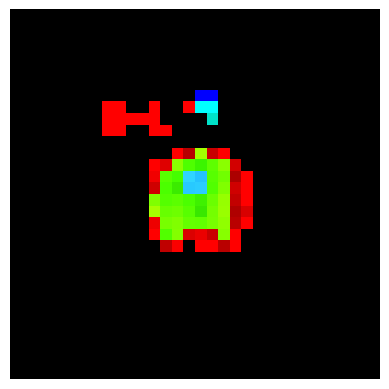

In [4]:
plt.imshow(train_imgs_tf[0,:,:])
plt.axis('off')
plt.show()

## Validation

In [5]:
extract_dir = "datos_im/validation/"
def list_all_files(directory):
    file_paths = []
    for root, directories, files in os.walk(directory):
        for filename in files:
            file_path = os.path.join(root, filename)
            file_paths.append(file_path)
    return file_paths

all_files = list_all_files(extract_dir)

image_files = [f for f in all_files if f.lower().endswith('.png')]

image_labels_val=[]
image_val = np.empty((len(image_files), *array_shape1),dtype=np.int8)
i=0

for file_path in image_files:
    image_name = os.path.basename(file_path).split('.png')[0]
    folder_name = os.path.basename(os.path.dirname(file_path)).split('_')[0]
    with Image.open(file_path) as img:
        img = img.convert('RGB')
        img = img.resize(array_shape)
        img_array = np.array(img)

    image_labels_val.append((image_name, folder_name))
    image_val[i]=img_array

    i+=1

val_imgs_tf = (image_val / 255)*np.pi

df_val = pd.DataFrame(image_labels_val, columns=['image_name', 'class'])
print(df_val.head())
print(df_val.shape)

print(val_imgs_tf.shape)

with open("datos_im/dfs/val_imgs_tf.pkl", "wb") as file:
    pickle.dump(val_imgs_tf, file)

with open("datos_im/dfs/df_val.pkl", "wb") as file:
    pickle.dump(df_val, file)

              image_name class
0   K2S1U6_11_12__radial     C
1    K2S1U6_11_5__radial     C
2   K2S1U6_11_6__circunf     C
3  K2S1U6_11_14__circunf     C
4   K2S1U6_11_15__radial     C
(416, 2)
(416, 32, 32, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


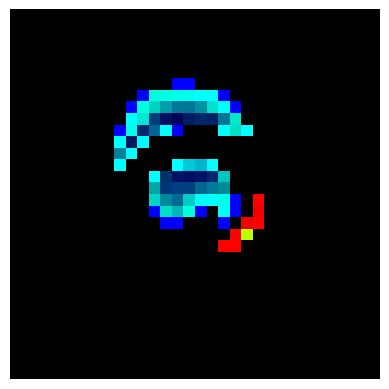

In [6]:
plt.imshow(val_imgs_tf[0,:,:])
plt.axis('off')
plt.show()

## Test

In [7]:
extract_dir = "datos_im/test/"
def list_all_files(directory):
    file_paths = []
    for root, directories, files in os.walk(directory):
        for filename in files:
            file_path = os.path.join(root, filename)
            file_paths.append(file_path)
    return file_paths

all_files = list_all_files(extract_dir)

image_files = [f for f in all_files if f.lower().endswith('.png')]

image_labels_test=[]
image_test = np.empty((len(image_files), *array_shape1),dtype=np.int8)
i=0

for file_path in image_files:
    image_name = os.path.basename(file_path).split('.png')[0]
    folder_name = os.path.basename(os.path.dirname(file_path)).split('_')[0]
    with Image.open(file_path) as img:
        img = img.convert('RGB')
        img = img.resize(array_shape)
        img_array = np.array(img)

    image_labels_test.append((image_name, folder_name))
    image_test[i]=img_array

    i+=1

test_imgs_tf = (image_test / 255)*np.pi

df_test = pd.DataFrame(image_labels_test, columns=['image_name', 'class'])
print(df_test.head())
print(df_test.shape)

print(test_imgs_tf.shape)

with open("datos_im/dfs/test_imgs_tf.pkl", "wb") as file:
    pickle.dump(test_imgs_tf, file)

with open("datos_im/dfs/df_test.pkl", "wb") as file:
    pickle.dump(df_test, file)

           image_name class
0  10013_8_13__radial    VI
1  10013_8_2__circunf    VI
2   10013_8_7__radial    VI
3   10013_8_8__radial    VI
4  10013_8_8__circunf    VI
(544, 2)
(544, 32, 32, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


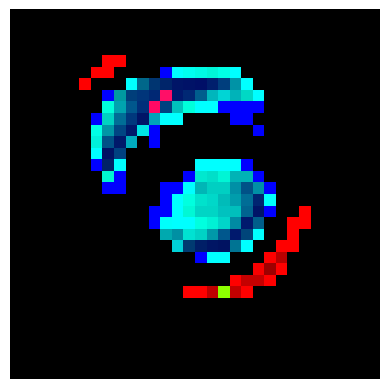

In [8]:
plt.imshow(test_imgs_tf[0,:,:])
plt.axis('off')
plt.show()

## Estadísticas de los datos

In [9]:
def plot_class_distribution(labels, dataset_name):
    unique_classes, counts = np.unique(labels, return_counts=True)
    plt.bar(unique_classes, counts)
    plt.title(f'Class Distribution in {dataset_name} Set')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()


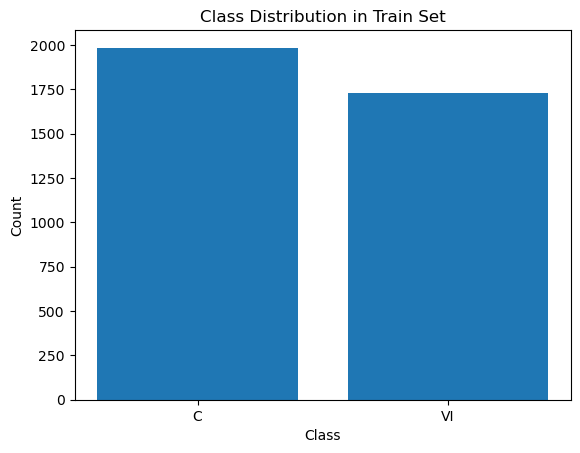

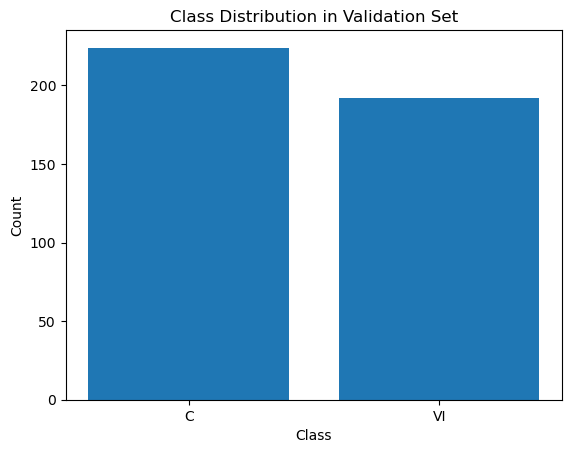

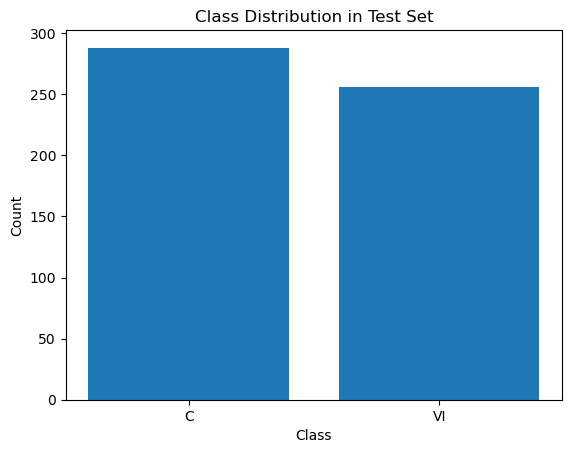

In [10]:
plot_class_distribution(df_tr["class"], 'Train')
plot_class_distribution(df_val["class"], 'Validation')
plot_class_distribution(df_test["class"], 'Test')

# Circuitos Cuánticos

In [11]:
n_qubits = 12
graphs = {
    "closed-nn" : [[0,6], [6,9], [9,3], [3,0], [0,1], [6,7], [9,10], [3,4], [1,7], [7,10], [10,4], [4,1], [1,2], [7,8], [10,11], [4,5], [2,8], [8,11], [11,5], [5,2]],
    "open-nn": [[0,1],[1,2],[2,8],[8,7],[7,6],[6,9],[9,10],[10,11],[11,5],[5,4],[4,3]]
}

dev = qml.device('default.qubit', wires=n_qubits)

## Closed

In [12]:
@qml.qnode(dev, interface="autograd")
def closed_circuit(params):
    """creates a quantum kernel based on a digital-analog quantum encoding.

    Args:
        params (torch.Parameters): trainable parameters

    Returns:
        list: expectation values of <Z> on each qubit
    """
    
    # DIGITAL ENCODING OF THE PIXELS
    for idx in range(n_qubits):
        qml.RY(params[idx], wires=idx)
        qml.Hadamard(wires=idx)
        
    # RYDBERG HAMILTONIAN EVOLUTION
    for t in [0.05, 0.1]:
        for qubit in range(n_qubits):
            qml.RX(t, wires=qubit)
            qml.RZ(t/2, wires=qubit)
        for pair in graphs["closed-nn"]:
            qml.CNOT(wires=[pair[0], pair[1]])
            qml.RZ(phi=np.pi/3, wires=pair[1])
            qml.CNOT(wires=[pair[0], pair[1]])
    
    # DIGITAL SINGLE-QUBIT OPERATIONS
    for qubit in range(n_qubits):
        qml.RY(np.pi/2, wires=qubit) 
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

## Opened

In [13]:
@qml.qnode(dev, interface="autograd")
def open_circuit(params):
    """creates a quantum kernel based on a digital-analog quantum encoding.

    Args:
        params (torch.Parameters): trainable parameters

    Returns:
        list: expectation values of <Z> on each qubit
    """
    
    # DIGITAL ENCODING OF THE PIXELS
    for idx in range(n_qubits):
        qml.RY(params[idx], wires=idx)
        qml.Hadamard(wires=idx)
        
    # RYDBERG HAMILTONIAN EVOLUTION
    for t in [0.05, 0.1]:
        for qubit in range(n_qubits):
            qml.RX(t, wires=qubit)
            qml.RZ(t/2, wires=qubit)
        for pair in graphs["open-nn"]:
            qml.CNOT(wires=[pair[0], pair[1]])
            qml.RZ(phi=np.pi/3, wires=pair[1])
            qml.CNOT(wires=[pair[0], pair[1]])
    
    # DIGITAL SINGLE-QUBIT OPERATIONS
    for qubit in range(n_qubits):
        qml.RY(np.pi/2, wires=qubit) 
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Quanvolución

In [14]:
def quanv(idx, image, folder):
    """Convolves the input image with many applications of the same quantum circuit."""
    out = np.zeros((array_shape[0]-1, array_shape[1]-1, 24))

    # Loop over the coordinates of the top-left pixel of 2X2 squares
    for j in range(0, array_shape[0]-1, 1):
        for k in range(0, array_shape[1]-1, 1):
            a0=image[j, k, 0]
            a1=image[j, k, 1]
            a2=image[j, k, 2]
            
            b0=image[j, k + 1, 0]
            b1=image[j, k + 1, 1]
            b2=image[j, k + 1, 2]
            
            c0=image[j + 1, k, 0]
            c1=image[j + 1, k, 1]
            c2=image[j + 1, k, 2]
            
            d0=image[j + 1, k + 1, 0]
            d1=image[j + 1, k + 1, 1]
            d2=image[j + 1, k + 1, 2]

            q1_results = closed_circuit( # circuit 2
                [
                    a0,
                    a1,
                    a2,
                    b0,
                    b1,
                    b2,
                    c0,
                    c1,
                    c2,
                    d0,
                    d1,
                    d2
                ]
            )
            q2_results = open_circuit( # circuit 3
                [
                    a0,
                    a1,
                    a2,
                    b0,
                    b1,
                    b2,
                    c0,
                    c1,
                    c2,
                    d0,
                    d1,
                    d2
                ]
            )

            for c in range(12):
                out[j, k, c] = q1_results[c]
            for c in range(12): 
                out[j, k, c+12] = q2_results[c]

    if folder=="train":
        with open(f"quantum/train/train_{idx}.pkl", "wb") as file:
            pickle.dump(out, file)
    elif folder=="validation":
        with open(f"quantum/validation/val_{idx}.pkl", "wb") as file:
            pickle.dump(out, file)
    elif folder=="test":
        with open(f"quantum/test/test_{idx}.pkl", "wb") as file:
            pickle.dump(out, file)

In [ ]:
if __name__=="__main__":
    num_cores = os.cpu_count() - 2
    
    pool_tr = Pool(processes=num_cores)
    pool_val = Pool(processes=num_cores)
    pool_test = Pool(processes=num_cores)
    
    # PROCCESS TRAIN DATA SET
    print("Quantum pre-processing of train images")
    for idx, img in enumerate(train_imgs_tf):
        pool_tr.apply_async(quanv, args=(idx,img,"train"))
    pool_tr.close()
    pool_tr.join()

    # PROCCESS VALIDATION DATA SET
    print("Quantum pre-processing of validation images")
    for idx, img in enumerate(val_imgs_tf):
        pool_val.apply_async(quanv, args=(idx,img,"validation"))
    pool_val.close()
    pool_val.join()
    
    # PROCCESS TEST DATA SET
    print("Quantum pre-processing of test images")
    for idx, img in enumerate(test_imgs_tf):
        pool_test.apply_async(quanv, args=(idx,img,"test"))
    pool_test.close()
    pool_test.join()

Quantum pre-processing of train images


In [14]:
def load_data_to_cpu(file_pattern, num_files):
    data_list = []
    for idx in range(num_files):
        with open(file_pattern.format(idx), "rb") as file:
            data = pickle.load(file)
        data_list.append(data)
    data_array = np.asarray(data_list)
    return data_array

In [15]:
def cpu_to_gpu(X):
    X_tensor = tf.convert_to_tensor(X)
    
    return tf.identity(X_tensor)

In [16]:
q_train_images = load_data_to_cpu("quantum/train/train_{}.pkl", len(train_imgs_tf))
print(q_train_images.shape)

q_val_images = load_data_to_cpu("quantum/validation/val_{}.pkl", len(val_imgs_tf))
print(q_val_images.shape)

q_test_images = load_data_to_cpu("quantum/test/test_{}.pkl", len(test_imgs_tf))
print(q_test_images.shape)

q_train_images_gpu = cpu_to_gpu(q_train_images)
print(q_train_images_gpu.shape)

q_val_images_gpu = cpu_to_gpu(q_val_images)
print(q_val_images_gpu.shape)

q_test_images_gpu = cpu_to_gpu(q_test_images)
print(q_test_images_gpu.shape)

(3712, 31, 31, 24)
(416, 31, 31, 24)
(544, 31, 31, 24)


2024-07-04 09:39:38.397388: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12508 MB memory:  -> device: 0, name: NVIDIA A16, pci bus id: 0000:85:00.0, compute capability: 8.6
2024-07-04 09:39:38.409460: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13222 MB memory:  -> device: 1, name: NVIDIA A16, pci bus id: 0000:86:00.0, compute capability: 8.6
2024-07-04 09:39:38.411704: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 13222 MB memory:  -> device: 2, name: NVIDIA A16, pci bus id: 0000:87:00.0, compute capability: 8.6
2024-07-04 09:39:38.413991: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 13222 MB memory:  -> device: 3, name: NVIDIA A16, pci bus id: 0000:88:00.0, compute capability: 8.6


Instructions for updating:
Use tf.identity instead.
(3712, 31, 31, 24)
(416, 31, 31, 24)
(544, 31, 31, 24)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


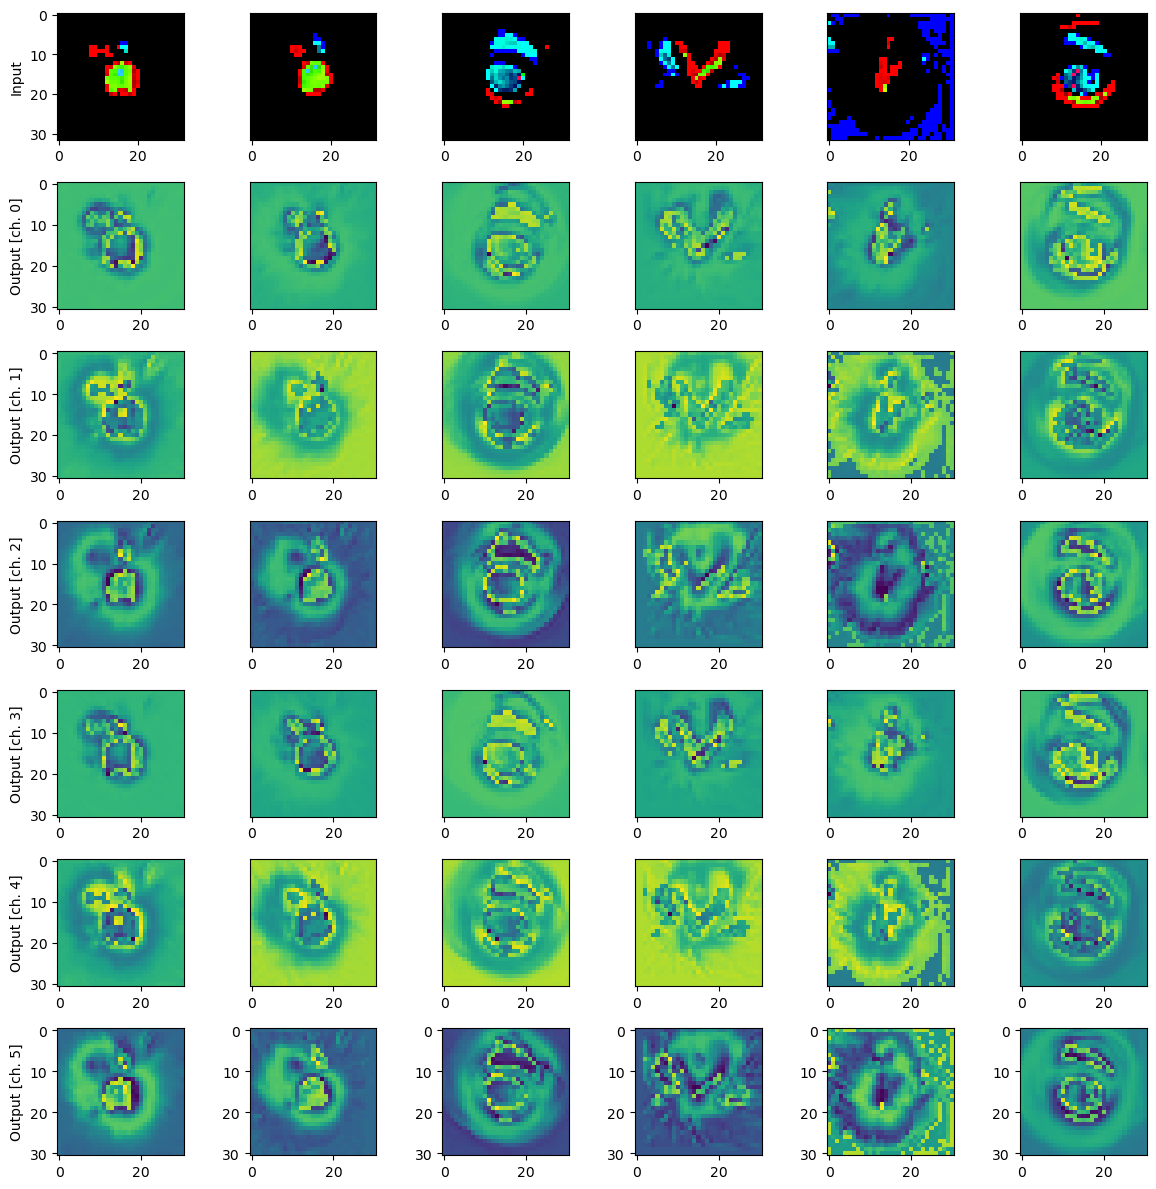

In [17]:
# PRINT SOME SAMPLES
n_samples = 6
n_channels = 6
fig, axes = plt.subplots(1 + n_channels, n_samples, figsize=(12, 12))
for k in range(n_samples):
    axes[0, 0].set_ylabel("Input")
    if k != 0:
        axes[0, k].yaxis.set_visible(False)
    axes[0, k].imshow(train_imgs_tf[k, :, :, :])

    # Plot all output channels
    for c in range(n_channels):
        axes[c + 1, 0].set_ylabel("Output [ch. {}]".format(c))
        if k != 0:
            axes[c, k].yaxis.set_visible(False)
        axes[c + 1, k].imshow(q_train_images[k, :, : ,c])

plt.tight_layout()
plt.show()

# Modelos básicos

In [18]:
def cnn(learning_rate, activation, dropout):
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    model = keras.models.Sequential([
        keras.layers.Conv3D(24, (2,2,3), strides = 1, activation='relu', input_shape=(array_shape[0],array_shape[1],3,1)), #Convolucion que sustituye a la cuantica
        keras.layers.Reshape((31, 31, 24)),
        keras.layers.Conv2D(32, 2, strides = 1, activation=activation, padding="same"),
        keras.layers.BatchNormalization(momentum=0.96),
        keras.layers.MaxPooling2D(pool_size=3),
        keras.layers.Conv2D(32, 2, strides = 1, activation=activation, trainable=True, padding="same"),
        keras.layers.Dropout(dropout),
        keras.layers.Flatten(),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return model

def qcnn(learning_rate, activation, dropout):
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    model = keras.models.Sequential([
        keras.layers.Conv2D(32, 2, strides = 1, activation=activation, input_shape=(array_shape[0]-1,array_shape[1]-1,24), padding="same"),
        keras.layers.BatchNormalization(momentum=0.96),
        keras.layers.MaxPooling2D(pool_size=3),
        keras.layers.Conv2D(32, 2, strides = 1, activation=activation, padding="same"),
        keras.layers.Dropout(dropout),
        keras.layers.Flatten(),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return model

In [19]:
# Verifica las dimensiones de las imágenes de entrenamiento
print(f'q_train_images shape: {q_train_images.shape}')
print(f'q_val_images shape: {q_val_images.shape}')
print(f'train_imgs_tf shape: {train_imgs_tf.shape}')
print(f'val_imgs_tf shape: {val_imgs_tf.shape}')

q_train_images shape: (3712, 31, 31, 24)
q_val_images shape: (416, 31, 31, 24)
train_imgs_tf shape: (3712, 32, 32, 3)
val_imgs_tf shape: (416, 32, 32, 3)


In [20]:
train_imgs_tf=train_imgs_tf.reshape((3712,32,32,3,1))
val_imgs_tf=val_imgs_tf.reshape((416,32,32,3,1))

In [21]:
print(f'train_imgs_tf shape: {train_imgs_tf.shape}')
print(f'val_imgs_tf shape: {val_imgs_tf.shape}')

train_imgs_tf shape: (3712, 32, 32, 3, 1)
val_imgs_tf shape: (416, 32, 32, 3, 1)


In [22]:
Encoder=LabelEncoder()

train_labels=Encoder.fit_transform(df_tr["class"].values)
val_labels=Encoder.fit_transform(df_val["class"].values)
test_labels=Encoder.fit_transform(df_test["class"].values)

## QCNN

In [38]:
q_model = qcnn(learning_rate = 0.001, activation = 'relu', dropout = 0.5)

q_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 31, 31, 32)     │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 31, 31, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         3,201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,561 (41.25 KB)

 Trainable params: 10,497 (41.00 KB)

 Non-trainable params: 64 (256.00 B)

In [39]:
q_history = q_model.fit(
    q_train_images_gpu,
    train_labels,
    validation_data=(q_val_images_gpu, val_labels),
    batch_size=128,
    epochs=200,
    verbose=2
)

Epoch 1/200
29/29 - 6s - 194ms/step - binary_accuracy: 0.5372 - loss: 0.8584 - val_binary_accuracy: 0.6058 - val_loss: 0.6851
Epoch 2/200
29/29 - 0s - 13ms/step - binary_accuracy: 0.6005 - loss: 0.6790 - val_binary_accuracy: 0.6202 - val_loss: 0.6751
Epoch 3/200
29/29 - 0s - 15ms/step - binary_accuracy: 0.6366 - loss: 0.6276 - val_binary_accuracy: 0.6587 - val_loss: 0.6431
Epoch 4/200
29/29 - 0s - 15ms/step - binary_accuracy: 0.6759 - loss: 0.6030 - val_binary_accuracy: 0.6707 - val_loss: 0.6098
Epoch 5/200
29/29 - 0s - 14ms/step - binary_accuracy: 0.7058 - loss: 0.5722 - val_binary_accuracy: 0.6947 - val_loss: 0.5788
Epoch 6/200
29/29 - 0s - 14ms/step - binary_accuracy: 0.7123 - loss: 0.5546 - val_binary_accuracy: 0.7163 - val_loss: 0.5573
Epoch 7/200
29/29 - 0s - 12ms/step - binary_accuracy: 0.7201 - loss: 0.5406 - val_binary_accuracy: 0.7380 - val_loss: 0.5543
Epoch 8/200
29/29 - 0s - 13ms/step - binary_accuracy: 0.7500 - loss: 0.5124 - val_binary_accuracy: 0.7596 - val_loss: 0.5311

In [42]:
q_predictions=q_model.predict(q_test_images_gpu)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


In [52]:
fprq, tprq, thresholdq = roc_curve(test_labels, q_predictions)

# AUC:
auc = roc_auc_score(test_labels, q_predictions)  

print("AUC:", auc)

# F1_score and recall:
f1 = f1_score(test_labels, np.round(q_predictions))

print('F1_Score:', f1)

# ACCURACY:
acc = accuracy_score(test_labels, np.round(q_predictions))
print('ACC:', acc)

AUC: 0.9296468098958333
F1_Score: 0.8464566929133858
ACC: 0.8566176470588235


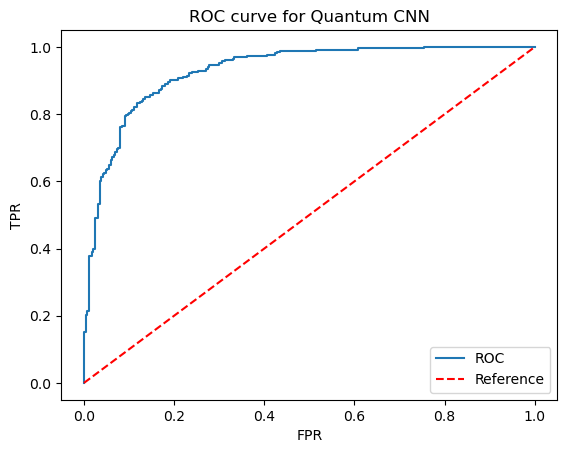

In [53]:
# Trazar la curva ROC
plt.plot(fprq, tprq, label='ROC')
plt.plot([0, 1], [0, 1], 'r--', label='Reference')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve for Quantum CNN')
plt.legend()
plt.show()

## CNN

In [40]:
c_model = cnn(learning_rate = 0.001, activation = 'relu', dropout = 0.5)

c_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 31, 31, 1, 24)  │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 31, 31, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 31, 31, 32)     │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 31, 31, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         3,201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,873 (42.47 KB)

 Trainable params: 10,809 (42.22 KB)

 Non-trainable params: 64 (256.00 B)

In [41]:
c_history = c_model.fit(
    train_imgs_tf,
    train_labels,
    validation_data=(val_imgs_tf, val_labels),
    batch_size=128,
    epochs=200,
    verbose=2,
)

Epoch 1/200
29/29 - 6s - 192ms/step - binary_accuracy: 0.5471 - loss: 0.7938 - val_binary_accuracy: 0.5889 - val_loss: 0.6881
Epoch 2/200
29/29 - 0s - 12ms/step - binary_accuracy: 0.5921 - loss: 0.6724 - val_binary_accuracy: 0.6442 - val_loss: 0.6749
Epoch 3/200
29/29 - 0s - 11ms/step - binary_accuracy: 0.6444 - loss: 0.6265 - val_binary_accuracy: 0.6635 - val_loss: 0.6421
Epoch 4/200
29/29 - 0s - 12ms/step - binary_accuracy: 0.6775 - loss: 0.5986 - val_binary_accuracy: 0.6755 - val_loss: 0.6052
Epoch 5/200
29/29 - 0s - 12ms/step - binary_accuracy: 0.6983 - loss: 0.5663 - val_binary_accuracy: 0.7236 - val_loss: 0.5691
Epoch 6/200
29/29 - 0s - 11ms/step - binary_accuracy: 0.7244 - loss: 0.5421 - val_binary_accuracy: 0.7163 - val_loss: 0.5445
Epoch 7/200
29/29 - 0s - 11ms/step - binary_accuracy: 0.7433 - loss: 0.5155 - val_binary_accuracy: 0.7404 - val_loss: 0.5321
Epoch 8/200
29/29 - 0s - 11ms/step - binary_accuracy: 0.7619 - loss: 0.4933 - val_binary_accuracy: 0.7115 - val_loss: 0.5301

In [48]:
c_predictions=c_model.predict(test_imgs_tf)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [54]:
fprq, tprq, thresholdq = roc_curve(test_labels, c_predictions)

# AUC:
auc = roc_auc_score(test_labels, c_predictions)  

print("AUC:", auc)

# F1_score and recall:
f1 = f1_score(test_labels, np.round(c_predictions))

print('F1_Score:', f1)

# ACCURACY:
acc = accuracy_score(test_labels, np.round(c_predictions))
print('ACC:', acc)

AUC: 0.9498019748263888
F1_Score: 0.8733944954128441
ACC: 0.8731617647058824


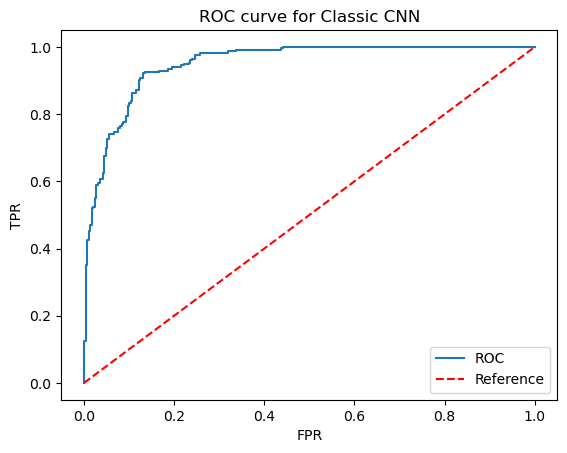

In [55]:

plt.plot(fprq, tprq, label='ROC')
plt.plot([0, 1], [0, 1], 'r--', label='Reference')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve for Classic CNN')
plt.legend()
plt.show()

# Robustez de los resultados

In [44]:
num_modelos= 30
classic_accuracies=[]
quantum_accuracies=[]

In [45]:
epochs=500

In [ ]:
for _ in range(num_modelos):
    c_model  = cnn(learning_rate = 0.001, activation = 'relu', dropout = 0.5)
    
    c_history = c_model.fit(
    train_imgs_tf,
    train_labels,
    validation_data=(val_imgs_tf, val_labels),
    batch_size=256,
    epochs=epochs,
    verbose=0)

    classic_accuracies.append(c_history.history['val_binary_accuracy'])

In [ ]:
for _ in range(num_modelos):
    q_model  = qcnn(learning_rate = 0.001, activation = 'relu', dropout = 0.5)
    
    q_history = q_model.fit(
    q_train_images_gpu,
    train_labels,
    validation_data=(q_val_images_gpu, val_labels),
    batch_size=256,
    epochs=epochs,
    verbose=0)

    quantum_accuracies.append(q_history.history['val_binary_accuracy'])

In [49]:
# Convert lists to numpy arrays for easier manipulation
q_accs = np.array(quantum_accuracies)
c_accs = np.array(classic_accuracies)

q_accs.shape
c_accs.shape 

(30, 500)

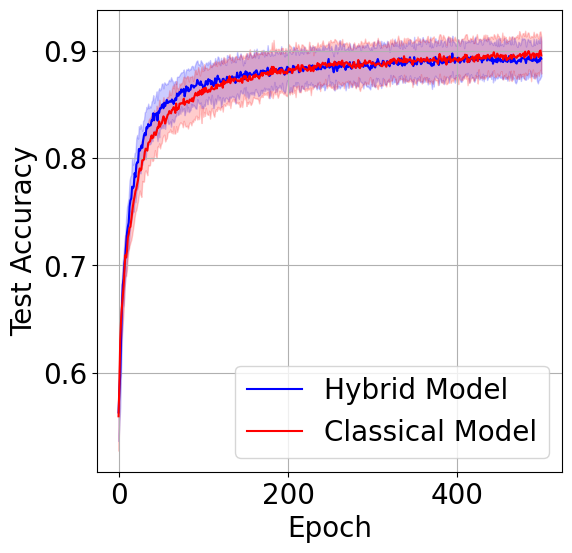

In [50]:
plt.rcParams.update({'font.size': 20})

# Calculate mean and standard deviation
q_mean = np.mean(q_accs, axis=0)
q_std = np.std(q_accs, axis=0)
c_mean = np.mean(c_accs, axis=0)
c_std = np.std(c_accs, axis=0)

# Plot the results
epochs = np.arange(500)
plt.figure(figsize=(6, 6))

# Quantum model plot
plt.plot(epochs, q_mean, label='Hybrid Model', color='blue')
plt.fill_between(epochs, q_mean - q_std, q_mean + q_std, color='blue', alpha=0.2)

# Classical model plot
plt.plot(epochs, c_mean, label='Classical Model', color='red')
plt.fill_between(epochs, c_mean - c_std, c_mean + c_std, color='red', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()